In [ ]:
%load_ext autoreload
%autoreload 2

# Import the library
import greenlearning as gl
import numpy as np

2025-09-18 12:06:03.811444: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Using TensorFlow 2 backend.

Instructions for updating:
non-resource variables are not supported in the long term


self.n_input 1
self.n_output 1
model.x.shape (100, 1)
model.y.shape (100, 1)
model.u.shape (100, 20)
model.f.shape (100, 20)
It: 0, Loss = 1.184e+00
It: 10, Loss = 9.658e-01
It: 20, Loss = 9.491e-01
It: 30, Loss = 9.372e-01
It: 40, Loss = 9.259e-01
It: 50, Loss = 9.184e-01
It: 60, Loss = 9.149e-01
It: 70, Loss = 9.129e-01
It: 80, Loss = 9.110e-01
It: 90, Loss = 9.099e-01
It: 100, Loss = 9.093e-01
It: 110, Loss = 9.088e-01
It: 120, Loss = 9.083e-01
It: 130, Loss = 9.079e-01
It: 140, Loss = 9.075e-01
It: 150, Loss = 9.070e-01
It: 160, Loss = 9.066e-01
It: 170, Loss = 9.061e-01
It: 180, Loss = 9.056e-01
It: 190, Loss = 9.050e-01
It: 200, Loss = 9.044e-01
It: 210, Loss = 9.037e-01
It: 220, Loss = 9.029e-01
It: 230, Loss = 9.019e-01
It: 240, Loss = 9.008e-01
It: 250, Loss = 8.995e-01
It: 260, Loss = 8.981e-01
It: 270, Loss = 8.966e-01
It: 280, Loss = 8.952e-01
It: 290, Loss = 8.937e-01
It: 300, Loss = 8.918e-01
It: 310, Loss = 8.889e-01
It: 320, Loss = 8.838e-01
It: 330, Loss = 8.729e-01
It

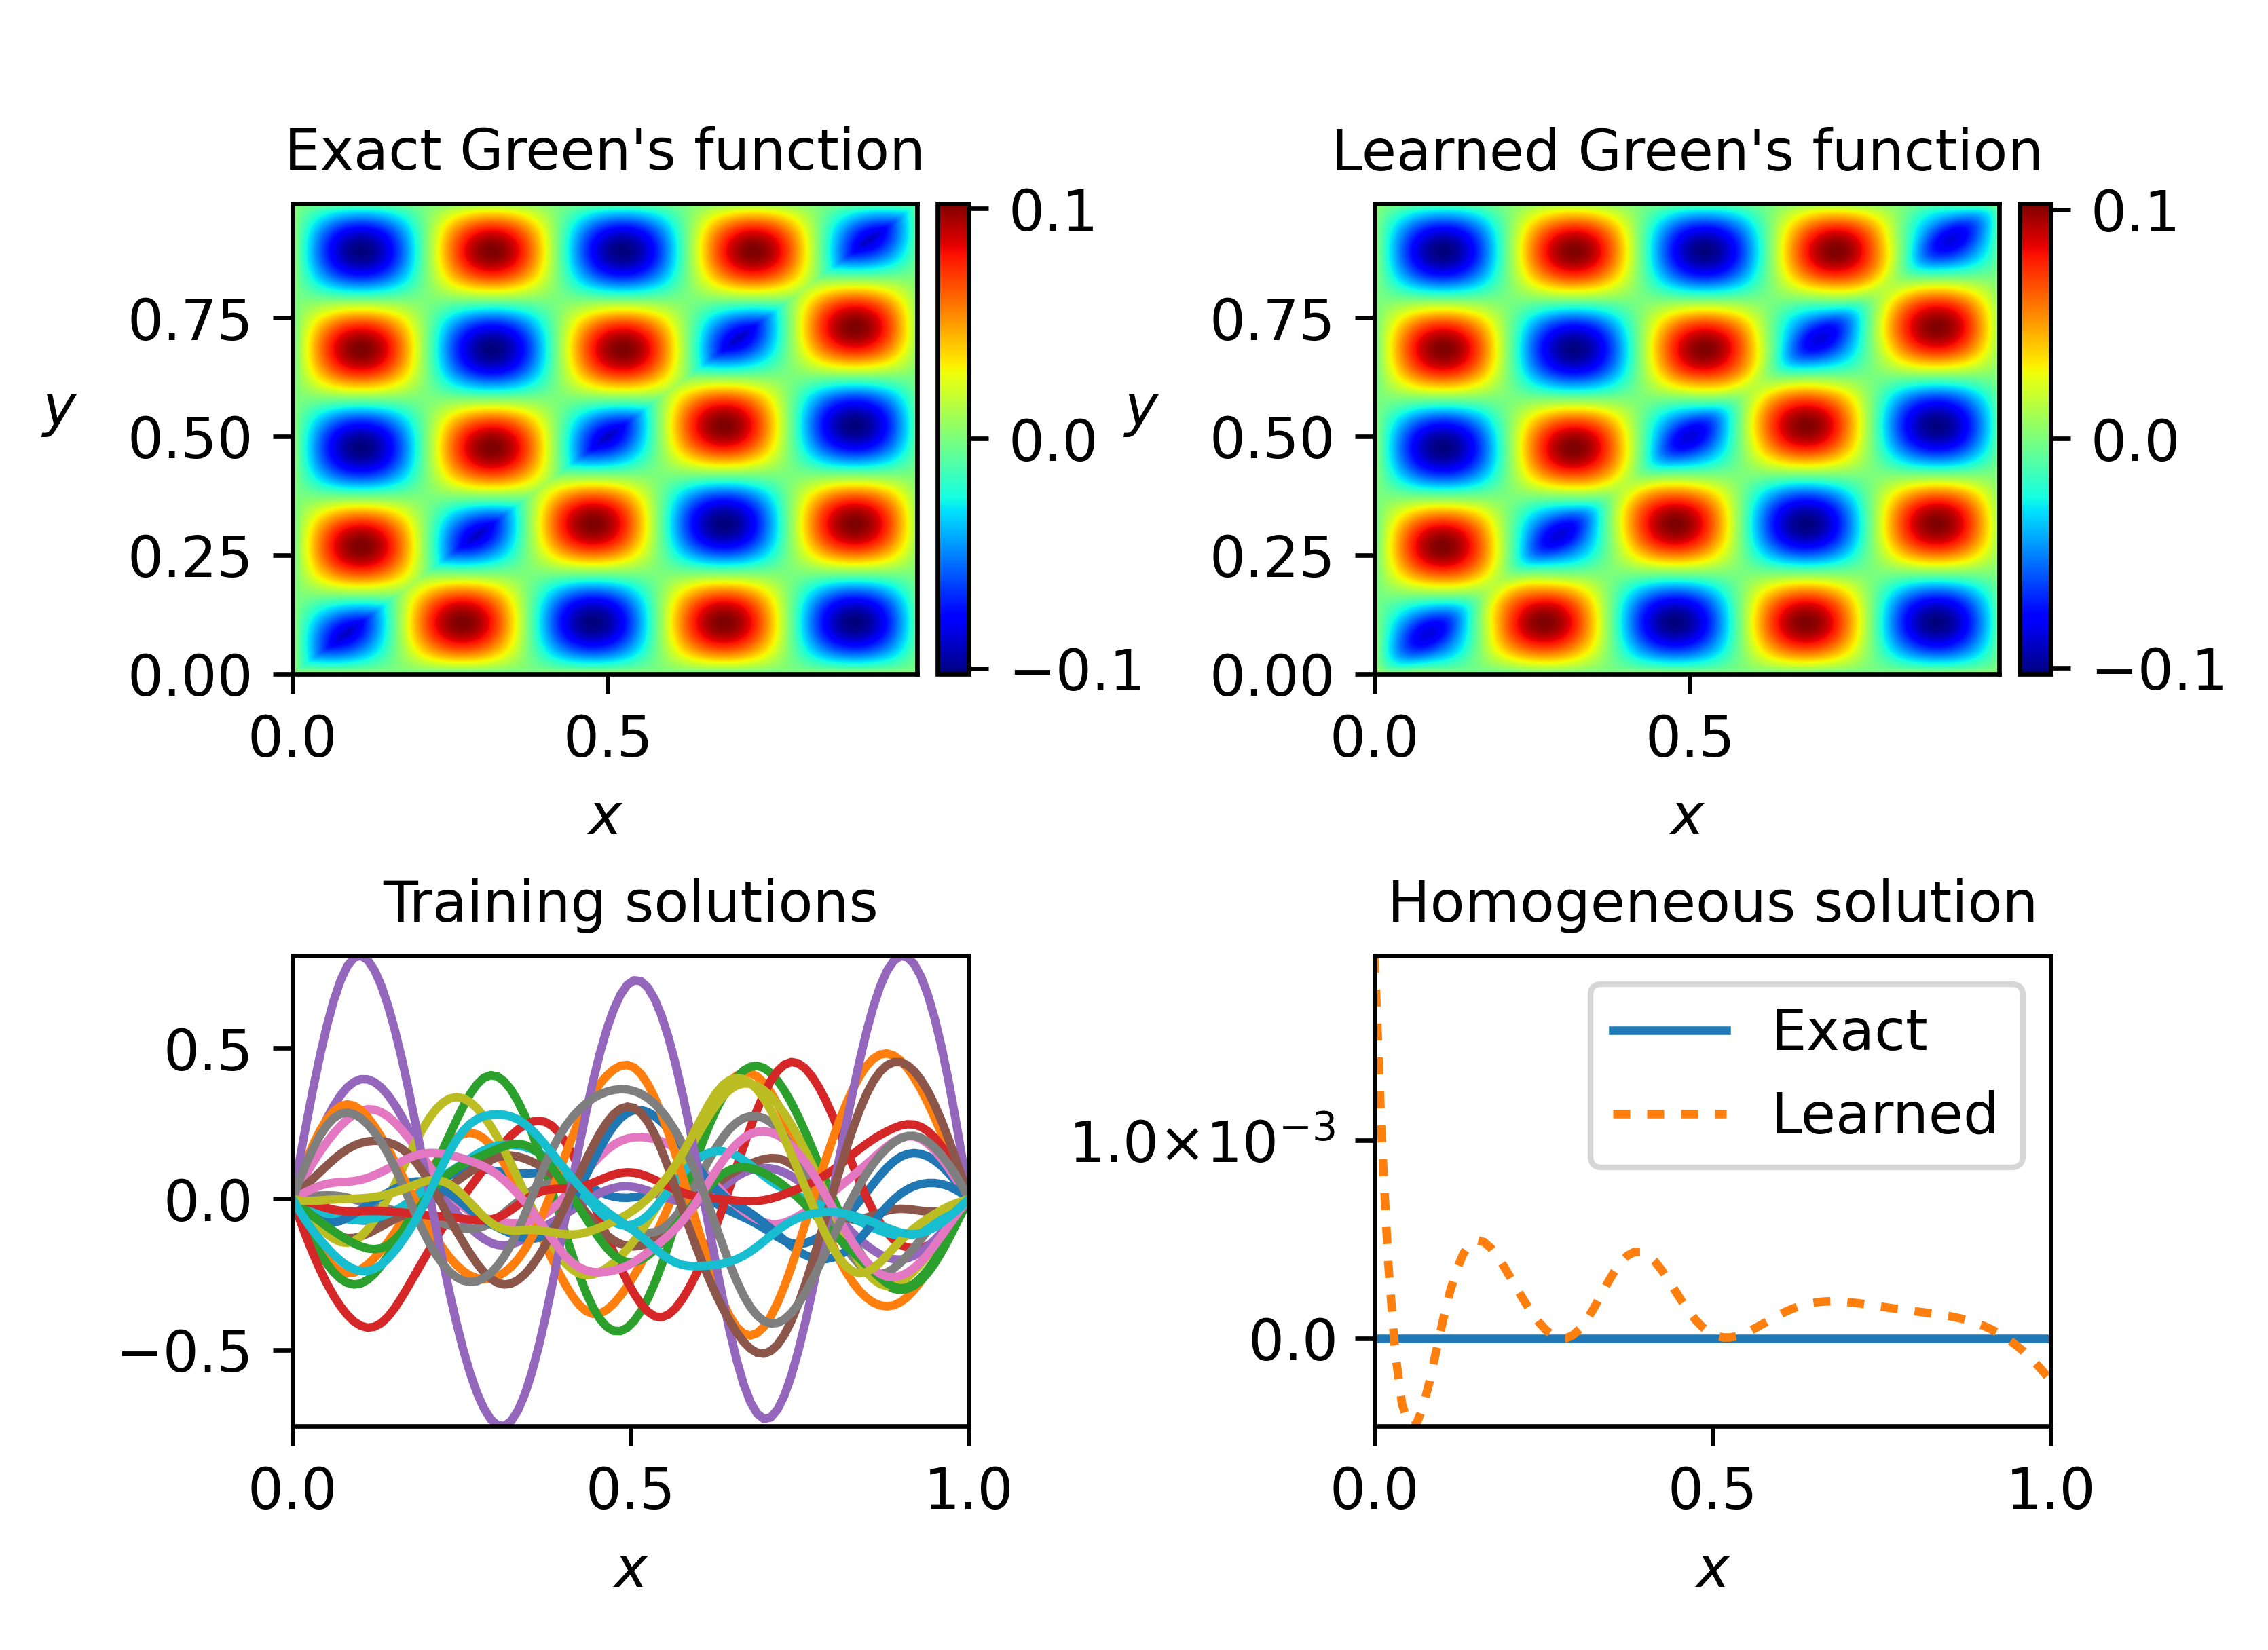

In [16]:
np.random.seed(42)

# Construct neural networks for G and homogeneous solution
G_network = gl.matrix_networks([2] + [50] * 4 + [1], "rational", (1,1))
U_hom_network = gl.matrix_networks([1] + [50] * 4 + [1], "rational", (1,))

# Define the model
model = gl.Model(G_network, U_hom_network) #, adam_steps=100, lbfgs_steps=100)

# Train the model on the dataset "helmholtz" in the path "examples/datasets/"
model.train("examples/datasets/","helmholtz", N_train=20, N_test=100, noise_ratio=0.0, resample=1)

# Save the training loss
model.save_loss()

# Plot the results
model.plot_results()

# Save the NNs evaluated at a grid in a csv file
model.save_results()

# Close the TensorFlow session
model.sess.close()